# Next Word Predictor - Week 7 Checkpoint

**Author:** Disha Janardhan

## Overview

This notebook builds on the Week 5 baseline (SGD Logistic Regression with TF-IDF features) to complete the Week 7 milestone. We:

1. **Experiment with feature representations** - Bag-of-Words vs TF-IDF
2. **Experiment with context window sizes** - 3, 4, and 5 words
3. **Train a Random Forest** on a smaller subset and discuss its suitability
4. **Train a simple MLP** (2–3 hidden layers) as a neural baseline
5. **Compare all models** on Top-1, Top-3, and Top-5 accuracy

All models use the same book-level train/validation split for fair comparison.

## Section 1 : Setup and Data Loading

In [1]:
import os
import re
import json
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder

# --- Reproducibility ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Hyperparameters (match Week 5) ---
CONTEXT_WINDOW = 4
TOP_N_VOCAB    = 10_000
MIN_WORD_FREQ  = 5
MAX_SAMPLES    = 500_000

# --- Directory setup ---
os.makedirs('outputs/figures', exist_ok=True)

print('Setup complete.')

Setup complete.


### 1.1 : Load vocabulary and book texts

We reload the vocabulary from Week 5 and re-clean the raw book texts using the same pipeline.

In [2]:
# Load vocabulary from Week 5
with open('data/processed/vocab.json', 'r') as f:
    word2idx = json.load(f)

print(f'Vocabulary size (incl. <UNK>): {len(word2idx):,}')

# Book IDs (same 50 books as Week 5)
BOOK_IDS = [
    1342, 11, 84, 1661, 2701, 98, 1400, 46, 76, 74,
    345, 1260, 768, 2554, 2600, 1080, 5200, 174, 244, 1232,
    2814, 4300, 16, 43, 120, 35, 36, 5230, 158, 161,
    105, 730, 3207, 7370, 61, 2265, 1514, 1522, 1513, 2641,
    2148, 600, 1184, 514, 1952, 3825, 1251, 23, 2097, 3296,
]

# Text cleaning (same as Week 5)
START_RE = re.compile(r'\*{3}\s*START OF (?:THE |THIS )?PROJECT GUTENBERG.*?\*{3}', re.IGNORECASE)
END_RE   = re.compile(r'\*{3}\s*END OF (?:THE |THIS )?PROJECT GUTENBERG.*?\*{3}', re.IGNORECASE)

def strip_gutenberg_boilerplate(text):
    start_match = START_RE.search(text)
    end_match   = END_RE.search(text)
    if start_match and end_match:
        return text[start_match.end():end_match.start()]
    elif start_match:
        return text[start_match.end():]
    return text

def clean_text(text):
    text = strip_gutenberg_boilerplate(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def map_token(tok):
    return tok if tok in word2idx else '<UNK>'

# Load and clean all books
cleaned_books = {}
downloaded = []
for bid in BOOK_IDS:
    path = f'data/raw/{bid}.txt'
    if os.path.exists(path):
        raw = open(path, encoding='utf-8', errors='replace').read()
        cleaned_books[bid] = clean_text(raw)
        downloaded.append(bid)

print(f'Books loaded: {len(downloaded)}')

Vocabulary size (incl. <UNK>): 10,001
Books loaded: 50


### 1.2 : Generate samples and build train/validation split

We use a helper function to generate sliding-window samples for any context window size. The book-level validation split uses a dedicated `random.Random(42)` instance for reproducibility.

In [3]:
def generate_samples(cleaned_books, downloaded, window_size, max_samples=500_000):
    """Generate (context, target, book_id) samples with a given window size."""
    per_book_cap = max(1, max_samples // len(downloaded))
    contexts, targets, book_ids = [], [], []

    for bid in downloaded:
        book_tokens = cleaned_books[bid].split()
        mapped = [map_token(tok) for tok in book_tokens]
        book_count = 0

        for i in range(len(mapped) - window_size):
            target_word = mapped[i + window_size]
            if target_word == '<UNK>':
                continue
            contexts.append(mapped[i : i + window_size])
            targets.append(target_word)
            book_ids.append(bid)
            book_count += 1
            if book_count >= per_book_cap:
                break

    return contexts, targets, book_ids


def build_split(contexts, targets, book_ids, downloaded, seed=42):
    """Book-level train/val split. Returns indices."""
    rng = random.Random(seed)
    n_val_books = max(1, round(0.15 * len(downloaded)))
    val_books = set(rng.sample(downloaded, n_val_books))

    train_idx = [i for i, bid in enumerate(book_ids) if bid not in val_books]
    val_idx   = [i for i, bid in enumerate(book_ids) if bid in val_books]
    return train_idx, val_idx, val_books


# Generate default (window=4) samples
contexts_4, targets_4, book_ids_4 = generate_samples(cleaned_books, downloaded, CONTEXT_WINDOW)

train_idx, val_idx, validation_books = build_split(contexts_4, targets_4, book_ids_4, downloaded)

# Encode targets : LabelEncoder is fit on all targets (train + val)
le = LabelEncoder()
y_all = le.fit_transform(targets_4)
y_train = y_all[train_idx]
y_val   = y_all[val_idx]

# Build context document strings
context_docs_4 = [' '.join(row) for row in contexts_4]
train_docs = [context_docs_4[i] for i in train_idx]
val_docs   = [context_docs_4[i] for i in val_idx]

# Diagnostic: class coverage between train and val
train_classes = set(np.unique(y_train))
val_classes   = set(np.unique(y_val))
val_only      = val_classes - train_classes
val_only_count = int(np.isin(y_val, list(val_only)).sum()) if val_only else 0

print(f'Total samples (window=4) : {len(contexts_4):,}')
print(f'Training samples         : {len(train_idx):,}')
print(f'Validation samples       : {len(val_idx):,}')
print(f'Validation books         : {sorted(validation_books)}')
print(f'Unique target classes    : {len(le.classes_):,}')
print()
print(f'Class coverage (book-level split):')
print(f'  Classes in training        : {len(train_classes):,}')
print(f'  Classes in validation      : {len(val_classes):,}')
print()
print(f'  Val-only classes (unseen)  : {len(val_only):,}')
print(f'  Val samples with unseen target: {val_only_count:,} ({val_only_count/len(val_idx)*100:.1f}%)')

Total samples (window=4) : 489,218
Training samples         : 416,025
Validation samples       : 73,193
Validation books         : [11, 46, 76, 174, 1080, 1400, 2148, 2600]
Unique target classes    : 9,406

Class coverage (book-level split):
  Classes in training        : 9,242
  Classes in validation      : 5,417

  Val-only classes (unseen)  : 164
  Val samples with unseen target: 958 (1.3%)


### 1.3 : Evaluation helper

A reusable function to compute Top-1, Top-3, and Top-5 accuracy for any model.

In [4]:
def evaluate_model(model, X_val, y_val, model_name='Model', batch_size=2000):
    """Compute Top-1, Top-3, Top-5 accuracy. Returns dict of results."""
    y_pred = model.predict(X_val)
    acc_top1 = accuracy_score(y_val, y_pred)

    top3_hits, top5_hits = 0, 0
    for start in range(0, len(y_val), batch_size):
        sl = slice(start, start + batch_size)
        scores = model.decision_function(X_val[sl])
        top5_cols = np.argpartition(scores, -5, axis=1)[:, -5:]
        top3_cols = np.argpartition(scores, -3, axis=1)[:, -3:]
        top5_classes = model.classes_[top5_cols]
        top3_classes = model.classes_[top3_cols]
        yb = y_val[sl]
        top3_hits += int(np.any(top3_classes == yb[:, None], axis=1).sum())
        top5_hits += int(np.any(top5_classes == yb[:, None], axis=1).sum())

    acc_top3 = top3_hits / len(y_val)
    acc_top5 = top5_hits / len(y_val)

    print(f'{model_name} : Validation Results:')
    print(f'  Top-1 Accuracy : {acc_top1:.4f}  ({acc_top1*100:.2f}%)')
    print(f'  Top-3 Accuracy : {acc_top3:.4f}  ({acc_top3*100:.2f}%)')
    print(f'  Top-5 Accuracy : {acc_top5:.4f}  ({acc_top5*100:.2f}%)')

    return {'model': model_name, 'top1': acc_top1, 'top3': acc_top3, 'top5': acc_top5}


def evaluate_mlp(model, X_val, y_val, model_name='MLP', batch_size=2000):
    """Evaluate MLP using predict_proba instead of decision_function."""
    y_pred = model.predict(X_val)
    acc_top1 = accuracy_score(y_val, y_pred)

    top3_hits, top5_hits = 0, 0
    for start in range(0, len(y_val), batch_size):
        sl = slice(start, start + batch_size)
        probs = model.predict_proba(X_val[sl])
        top5_cols = np.argpartition(probs, -5, axis=1)[:, -5:]
        top3_cols = np.argpartition(probs, -3, axis=1)[:, -3:]
        top5_classes = model.classes_[top5_cols]
        top3_classes = model.classes_[top3_cols]
        yb = y_val[sl]
        top3_hits += int(np.any(top3_classes == yb[:, None], axis=1).sum())
        top5_hits += int(np.any(top5_classes == yb[:, None], axis=1).sum())

    acc_top3 = top3_hits / len(y_val)
    acc_top5 = top5_hits / len(y_val)

    print(f'{model_name} : Validation Results:')
    print(f'  Top-1 Accuracy : {acc_top1:.4f}  ({acc_top1*100:.2f}%)')
    print(f'  Top-3 Accuracy : {acc_top3:.4f}  ({acc_top3*100:.2f}%)')
    print(f'  Top-5 Accuracy : {acc_top5:.4f}  ({acc_top5*100:.2f}%)')

    return {'model': model_name, 'top1': acc_top1, 'top3': acc_top3, 'top5': acc_top5}


# Store all results for final comparison
all_results = []
print('Evaluation helpers ready.')

Evaluation helpers ready.


## Section 2 : Feature Representation: Bag-of-Words vs TF-IDF

In Week 5 we used TF-IDF exclusively. Here we compare it with a plain Bag-of-Words (count) representation to understand whether TF-IDF's frequency weighting actually helps.

**Bag-of-Words** treats each word equally : a context window is represented by raw word counts.
**TF-IDF** downweights very common words (low IDF) that appear in nearly every window, giving more influence to rarer, more informative words.

In [5]:
# 2.1 : Build TF-IDF and BoW feature matrices
vocab_list = list(word2idx.keys())

# TF-IDF (same setup as Week 5)
tfidf = TfidfVectorizer(vocabulary=vocab_list, sublinear_tf=True, ngram_range=(1, 1))
tfidf.fit(train_docs)
X_train_tfidf = tfidf.transform(train_docs)
X_val_tfidf   = tfidf.transform(val_docs)

# Bag-of-Words
bow = CountVectorizer(vocabulary=vocab_list, ngram_range=(1, 1))
bow.fit(train_docs)
X_train_bow = bow.transform(train_docs)
X_val_bow   = bow.transform(val_docs)

print(f'TF-IDF shape : {X_train_tfidf.shape}')
print(f'BoW shape    : {X_train_bow.shape}')

TF-IDF shape : (416025, 10001)
BoW shape    : (416025, 10001)


In [6]:
# 2.2 : Train SGD Logistic Regression on TF-IDF
print('Training LR on TF-IDF features...')
lr_tfidf = SGDClassifier(
    loss='log_loss', penalty='l2', alpha=1e-4,
    max_iter=20, tol=1e-3, n_iter_no_change=3,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=0,
)
lr_tfidf.fit(X_train_tfidf, y_train)
result_tfidf = evaluate_model(lr_tfidf, X_val_tfidf, y_val, 'LR + TF-IDF')
all_results.append(result_tfidf)

Training LR on TF-IDF features...
LR + TF-IDF : Validation Results:
  Top-1 Accuracy : 0.0691  (6.91%)
  Top-3 Accuracy : 0.1509  (15.09%)
  Top-5 Accuracy : 0.1956  (19.56%)


In [7]:
# 2.3 : Train SGD Logistic Regression on Bag-of-Words
print('Training LR on BoW features...')
lr_bow = SGDClassifier(
    loss='log_loss', penalty='l2', alpha=1e-4,
    max_iter=20, tol=1e-3, n_iter_no_change=3,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=0,
)
lr_bow.fit(X_train_bow, y_train)
result_bow = evaluate_model(lr_bow, X_val_bow, y_val, 'LR + BoW')
all_results.append(result_bow)

Training LR on BoW features...
LR + BoW : Validation Results:
  Top-1 Accuracy : 0.0854  (8.54%)
  Top-3 Accuracy : 0.1686  (16.86%)
  Top-5 Accuracy : 0.2196  (21.96%)


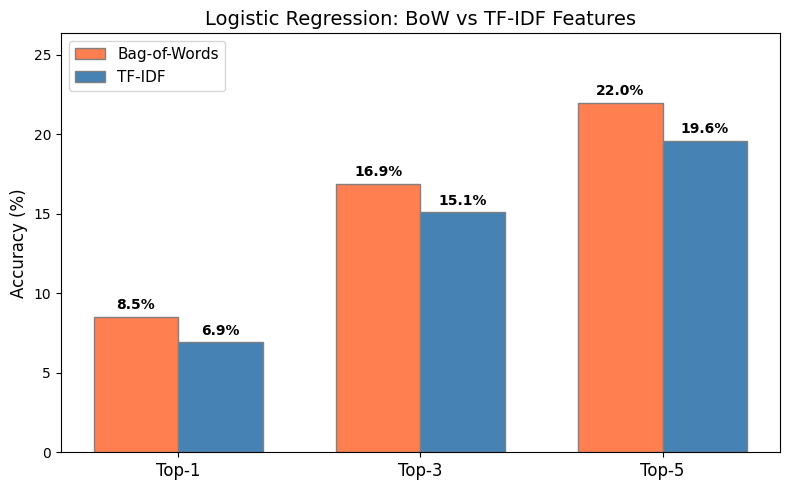

In [8]:
# 2.4 : Figure: BoW vs TF-IDF comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
metrics = ['Top-1', 'Top-3', 'Top-5']

bow_vals  = [result_bow['top1']*100,  result_bow['top3']*100,  result_bow['top5']*100]
tfidf_vals = [result_tfidf['top1']*100, result_tfidf['top3']*100, result_tfidf['top5']*100]

bars1 = ax.bar(x - width/2, bow_vals, width, label='Bag-of-Words', color='coral', edgecolor='grey')
bars2 = ax.bar(x + width/2, tfidf_vals, width, label='TF-IDF', color='steelblue', edgecolor='grey')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Logistic Regression: BoW vs TF-IDF Features', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(bow_vals), max(tfidf_vals)) * 1.2)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/bow_vs_tfidf.png', dpi=150)
plt.show()

## Section 3 : Context Window Size Experiments

We test whether providing more context words helps the model. A larger window gives more information but also increases sparsity in the bag-of-words representation (since TF-IDF still treats word order as irrelevant). We compare window sizes of 3, 4, and 5 words, all using TF-IDF features and the same SGD Logistic Regression.

In [9]:
# 3.1 : Train LR for window sizes 3, 4, and 5
window_results = []

for ws in [3, 4, 5]:
    print(f'\n{"="*50}')
    print(f'Window size = {ws}')
    print(f'{"="*50}')

    # Generate samples
    ctx, tgt, bids = generate_samples(cleaned_books, downloaded, ws)
    tr_idx, vl_idx, _ = build_split(ctx, tgt, bids, downloaded)

    # Encode targets
    le_ws = LabelEncoder()
    y_ws = le_ws.fit_transform(tgt)
    y_tr_ws = y_ws[tr_idx]
    y_vl_ws = y_ws[vl_idx]

    # Build TF-IDF
    docs_ws = [' '.join(row) for row in ctx]
    tr_docs_ws = [docs_ws[i] for i in tr_idx]
    vl_docs_ws = [docs_ws[i] for i in vl_idx]

    tfidf_ws = TfidfVectorizer(vocabulary=vocab_list, sublinear_tf=True, ngram_range=(1, 1))
    tfidf_ws.fit(tr_docs_ws)
    X_tr_ws = tfidf_ws.transform(tr_docs_ws)
    X_vl_ws = tfidf_ws.transform(vl_docs_ws)

    print(f'  Train: {X_tr_ws.shape[0]:,}  Val: {X_vl_ws.shape[0]:,}  Classes: {len(le_ws.classes_):,}')

    # Train
    lr_ws = SGDClassifier(
        loss='log_loss', penalty='l2', alpha=1e-4,
        max_iter=20, tol=1e-3, n_iter_no_change=3,
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0,
    )
    lr_ws.fit(X_tr_ws, y_tr_ws)
    res = evaluate_model(lr_ws, X_vl_ws, y_vl_ws, f'LR (window={ws})')
    res['window'] = ws
    window_results.append(res)

print('\n Final Comparison ')
for r in window_results:
    print(f"  window={r['window']}:  Top-1={r['top1']*100:.2f}%  Top-3={r['top3']*100:.2f}%  Top-5={r['top5']*100:.2f}%")


Window size = 3
  Train: 416,026  Val: 73,194  Classes: 9,406
LR (window=3) : Validation Results:
  Top-1 Accuracy : 0.0735  (7.35%)
  Top-3 Accuracy : 0.1527  (15.27%)
  Top-5 Accuracy : 0.1984  (19.84%)

Window size = 4
  Train: 416,025  Val: 73,193  Classes: 9,406
LR (window=4) : Validation Results:
  Top-1 Accuracy : 0.0691  (6.91%)
  Top-3 Accuracy : 0.1509  (15.09%)
  Top-5 Accuracy : 0.1956  (19.56%)

Window size = 5
  Train: 416,024  Val: 73,193  Classes: 9,406
LR (window=5) : Validation Results:
  Top-1 Accuracy : 0.0657  (6.57%)
  Top-3 Accuracy : 0.1458  (14.58%)
  Top-5 Accuracy : 0.1913  (19.13%)

 Final Comparison 
  window=3:  Top-1=7.35%  Top-3=15.27%  Top-5=19.84%
  window=4:  Top-1=6.91%  Top-3=15.09%  Top-5=19.56%
  window=5:  Top-1=6.57%  Top-3=14.58%  Top-5=19.13%


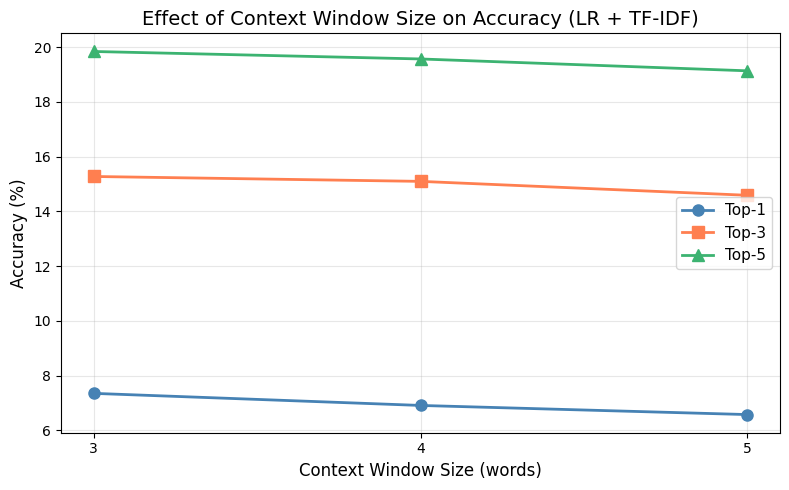

In [10]:
# 3.2 : Figure: Accuracy vs context window size
fig, ax = plt.subplots(figsize=(8, 5))
windows = [r['window'] for r in window_results]

ax.plot(windows, [r['top1']*100 for r in window_results], 'o-', label='Top-1', color='steelblue', linewidth=2, markersize=8)
ax.plot(windows, [r['top3']*100 for r in window_results], 's-', label='Top-3', color='coral', linewidth=2, markersize=8)
ax.plot(windows, [r['top5']*100 for r in window_results], '^-', label='Top-5', color='mediumseagreen', linewidth=2, markersize=8)

ax.set_xlabel('Context Window Size (words)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Effect of Context Window Size on Accuracy (LR + TF-IDF)', fontsize=14)
ax.set_xticks(windows)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/window_size_comparison.png', dpi=150)
plt.show()

## Section 4 : Random Forest

Random Forest is a classical ML model that works well for many classification tasks, but it faces challenges with this problem:

- **High dimensionality:** 10,001 TF-IDF features make tree splits expensive
- **Many classes:** ~9,000+ target classes means the model must learn thousands of decision boundaries
- **Memory:** Each tree stores split thresholds for every node, and with many classes this grows quickly

We train on a **smaller subset** (~50,000 samples) to keep training tractable, and document the results whether successful or not.

In [11]:
# 4.1 : Train Random Forest on a subset
RF_SUBSET = 50_000

# Subsample training data
rng_rf = np.random.RandomState(RANDOM_SEED)
rf_indices = rng_rf.choice(len(y_train), size=min(RF_SUBSET, len(y_train)), replace=False)
X_train_rf = X_train_tfidf[rf_indices]
y_train_rf = y_train[rf_indices]

print(f'Random Forest training subset: {X_train_rf.shape[0]:,} samples')
print(f'Unique classes in subset: {len(np.unique(y_train_rf)):,}')
print()

import time
print('Training Random Forest (this may take a few minutes)...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_split=5,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0,
)
rf.fit(X_train_rf, y_train_rf)
train_time = time.time() - t0
print(f'Training complete in {train_time:.1f}s')

Random Forest training subset: 50,000 samples
Unique classes in subset: 5,589

Training Random Forest (this may take a few minutes)...
Training complete in 7.8s


In [12]:
# 4.2 : Evaluate Random Forest
# Evaluate on a 10k random subset instead.
RF_VAL_SUBSET = 10_000
rng_val = np.random.RandomState(RANDOM_SEED)
rf_val_idx = rng_val.choice(len(y_val), size=min(RF_VAL_SUBSET, len(y_val)), replace=False)
X_val_rf = X_val_tfidf[rf_val_idx]
y_val_rf = y_val[rf_val_idx]

print(f'Evaluating RF on {len(y_val_rf):,} validation samples (subset for memory)')

# Single pass: use predict_proba to get top-1, top-3, top-5
BATCH = 1000
top1_hits_rf, top3_hits_rf, top5_hits_rf = 0, 0, 0
for start in range(0, len(y_val_rf), BATCH):
    sl = slice(start, start + BATCH)
    probs = rf.predict_proba(X_val_rf[sl])
    yb = y_val_rf[sl]

    top1_classes = rf.classes_[np.argmax(probs, axis=1)]
    top1_hits_rf += int((top1_classes == yb).sum())

    k5 = min(5, probs.shape[1])
    k3 = min(3, probs.shape[1])
    top5_cols = np.argpartition(probs, -k5, axis=1)[:, -k5:]
    top3_cols = np.argpartition(probs, -k3, axis=1)[:, -k3:]
    top5_classes = rf.classes_[top5_cols]
    top3_classes = rf.classes_[top3_cols]
    top3_hits_rf += int(np.any(top3_classes == yb[:, None], axis=1).sum())
    top5_hits_rf += int(np.any(top5_classes == yb[:, None], axis=1).sum())

acc_top1_rf = top1_hits_rf / len(y_val_rf)
acc_top3_rf = top3_hits_rf / len(y_val_rf)
acc_top5_rf = top5_hits_rf / len(y_val_rf)

result_rf = {'model': 'Random Forest', 'top1': acc_top1_rf, 'top3': acc_top3_rf, 'top5': acc_top5_rf}
all_results.append(result_rf)

# Class coverage analysis
rf_val_classes = set(np.unique(y_val_rf))
rf_classes     = set(rf.classes_)
missing = rf_val_classes - rf_classes
unreachable = int(np.isin(y_val_rf, list(missing)).sum()) if missing else 0

print(f'\nRandom Forest : Validation Results:')
print(f'  Top-1 Accuracy : {acc_top1_rf:.4f}  ({acc_top1_rf*100:.2f}%)')
print(f'  Top-3 Accuracy : {acc_top3_rf:.4f}  ({acc_top3_rf*100:.2f}%)')
print(f'  Top-5 Accuracy : {acc_top5_rf:.4f}  ({acc_top5_rf*100:.2f}%)')
print(f'  Trained on     : {RF_SUBSET:,} samples')
print(f'  Evaluated on   : {len(y_val_rf):,} samples')
print()
print(f'  Class coverage:')
print(f'    Classes in val subset    : {len(rf_val_classes):,}')
print(f'    Classes seen by RF       : {len(rf_classes):,}')
print(f'    Classes missing from RF  : {len(missing):,}')
print(f'    Val samples with unseen class: {unreachable:,} ({unreachable/len(y_val_rf)*100:.1f}%)')

Evaluating RF on 10,000 validation samples (subset for memory)

Random Forest : Validation Results:
  Top-1 Accuracy : 0.0588  (5.88%)
  Top-3 Accuracy : 0.1374  (13.74%)
  Top-5 Accuracy : 0.1791  (17.91%)
  Trained on     : 50,000 samples
  Evaluated on   : 10,000 samples

  Class coverage:
    Classes in val subset    : 2,045
    Classes seen by RF       : 5,589
    Classes missing from RF  : 435
    Val samples with unseen class: 591 (5.9%)


## Section 5 : MLP (Multi-Layer Perceptron)

Train a simple neural network with 2–3 hidden layers using sklearn's `MLPClassifier`. This uses the same TF-IDF features as the other models for a fair comparison.

The MLP differs from Logistic Regression in that it can learn **non-linear** combinations of features through its hidden layers. 

In [13]:
# 5.1 : Train MLP
print('Training MLP...')
t0 = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=1024,
    max_iter=30,
    early_stopping=True,
    n_iter_no_change=5,
    validation_fraction=0.1,
    random_state=RANDOM_SEED,
    verbose=True,
)
mlp.fit(X_train_tfidf, y_train)
mlp_time = time.time() - t0
print(f'\nTraining complete in {mlp_time:.1f}s')
print(f'Iterations run: {mlp.n_iter_}')

Training MLP...
Iteration 1, loss = 6.71968089
Validation score: 0.054684
Iteration 2, loss = 6.49084858
Validation score: 0.058650
Iteration 3, loss = 6.33930916
Validation score: 0.080571
Iteration 4, loss = 6.14978380
Validation score: 0.088599
Iteration 5, loss = 5.94600605
Validation score: 0.091820
Iteration 6, loss = 5.73301168
Validation score: 0.093214
Iteration 7, loss = 5.51588743
Validation score: 0.093647
Iteration 8, loss = 5.29990430
Validation score: 0.091460
Iteration 9, loss = 5.08772293
Validation score: 0.088647
Iteration 10, loss = 4.88208836
Validation score: 0.088215
Iteration 11, loss = 4.67788762
Validation score: 0.085811
Iteration 12, loss = 4.47931495
Validation score: 0.082037
Iteration 13, loss = 4.28210359
Validation score: 0.078696
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.

Training complete in 3584.2s
Iterations run: 13


In [14]:
# 5.2 : Evaluate MLP
result_mlp = evaluate_mlp(mlp, X_val_tfidf, y_val, 'MLP (512-256-128)')
all_results.append(result_mlp)

MLP (512-256-128) : Validation Results:
  Top-1 Accuracy : 0.0903  (9.03%)
  Top-3 Accuracy : 0.1674  (16.74%)
  Top-5 Accuracy : 0.2155  (21.55%)


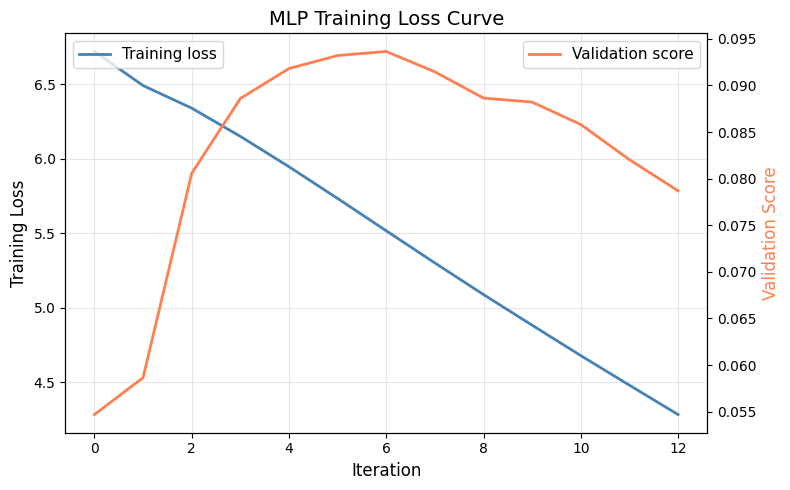

In [15]:
# 5.3 : Figure: MLP training loss curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mlp.loss_curve_, linewidth=2, color='steelblue', label='Training loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, linewidth=2, color='coral', label='Validation score')
    ax2.set_ylabel('Validation Score', fontsize=12, color='coral')
    ax2.legend(loc='upper right', fontsize=11)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('MLP Training Loss Curve', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/mlp_loss_curve.png', dpi=150)
plt.show()

## Section 6 : Model Comparison

In [20]:
# 6.1 : Summary table
df_results = pd.DataFrame(all_results)
df_results['top1_pct'] = (df_results['top1'] * 100).round(2)
df_results['top3_pct'] = (df_results['top3'] * 100).round(2)
df_results['top5_pct'] = (df_results['top5'] * 100).round(2)

random_baseline = 1 / len(le.classes_) * 100

print('=' * 65)
print('MODEL COMPARISON : ALL MODELS')
print('=' * 65)
print(df_results[['model', 'top1_pct', 'top3_pct', 'top5_pct']].to_string(index=False))
print(f'\nRandom baseline from week 5: {random_baseline:.4f}%')
print('=' * 65)

MODEL COMPARISON : ALL MODELS
            model  top1_pct  top3_pct  top5_pct
      LR + TF-IDF      6.91     15.09     19.56
         LR + BoW      8.54     16.86     21.96
    Random Forest      5.88     13.74     17.91
MLP (512-256-128)      9.03     16.74     21.55

Random baseline from week 5: 0.0106%


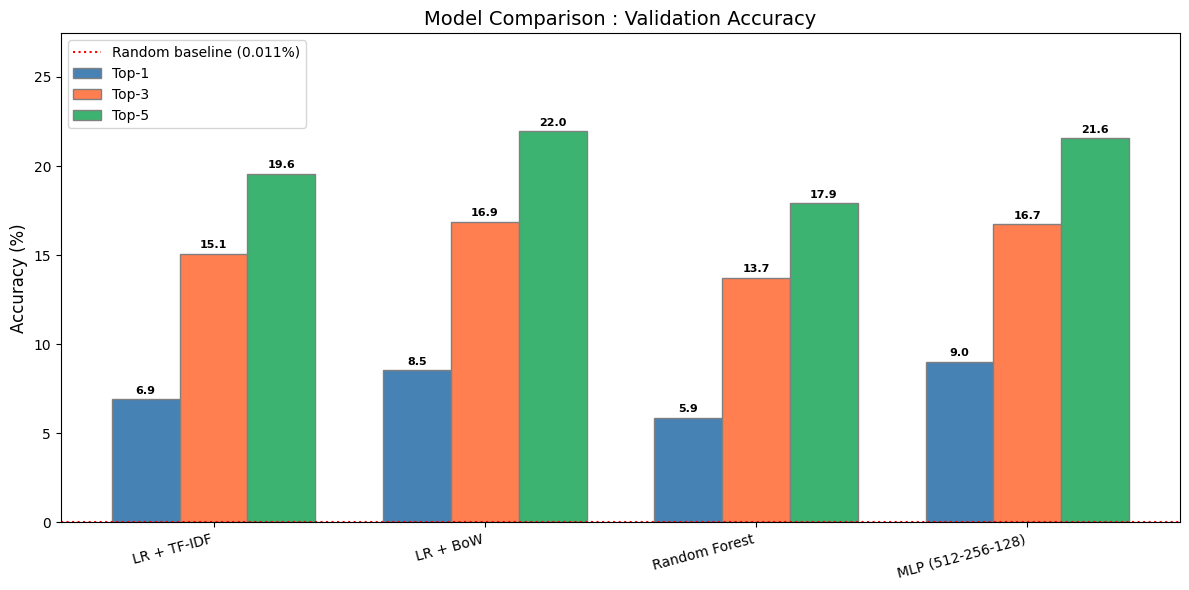

In [21]:
# 6.2 : Figure: Grouped bar chart comparing all models
fig, ax = plt.subplots(figsize=(12, 6))

models = df_results['model'].tolist()
x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, df_results['top1_pct'], width, label='Top-1', color='steelblue', edgecolor='grey')
bars2 = ax.bar(x, df_results['top3_pct'], width, label='Top-3', color='coral', edgecolor='grey')
bars3 = ax.bar(x + width, df_results['top5_pct'], width, label='Top-5', color='mediumseagreen', edgecolor='grey')

ax.axhline(y=random_baseline, color='red', linestyle=':', linewidth=1.5, label=f'Random baseline ({random_baseline:.3f}%)')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison : Validation Accuracy', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.set_ylim(0, df_results['top5_pct'].max() * 1.25)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/model_comparison.png', dpi=150)
plt.show()

## Section 7 : Qualitative Predictions

We run the same example prompts from Week 5 through each model to see how their predictions differ.

In [18]:
# 7.1 : Prediction comparison across models
def predict_top5(prompt, model, tfidf_vec, label_enc, word_to_idx, use_proba=False):
    """Return top-5 predicted words for a prompt."""
    words = re.sub(r"[^a-z\s']", ' ', prompt.lower()).split()
    words = [w if w in word_to_idx else '<UNK>' for w in words]
    context = words[-CONTEXT_WINDOW:]
    if len(context) < CONTEXT_WINDOW:
        context = ['the'] * (CONTEXT_WINDOW - len(context)) + context

    doc = ' '.join(context)
    X = tfidf_vec.transform([doc])

    if use_proba:
        scores = model.predict_proba(X)[0]
    else:
        scores = model.decision_function(X)[0]

    top_cols = np.argpartition(scores, -5)[-5:]
    top_cols = top_cols[np.argsort(scores[top_cols])[::-1]]
    top_classes = model.classes_[top_cols]
    return label_enc.classes_[top_classes].tolist()


prompts = [
    'it was the best of',
    'to be or not to',
    'she opened the door',
]

model_configs = [
    ('LR + TF-IDF',     lr_tfidf, False),
    ('LR + BoW',        lr_bow,   False),
    ('Random Forest',   rf,       True),
    ('MLP (512-256-128)', mlp,    True),
]

for prompt in prompts:
    print(f'\nPrompt: "{prompt}"')
    print('-' * 60)
    for name, model, use_proba in model_configs:
        vec = tfidf if not (name == 'LR + BoW') else bow
        preds = predict_top5(prompt, model, vec, le, word2idx, use_proba=use_proba)
        print(f'  {name:20s} --> {preds}')


Prompt: "it was the best of"
------------------------------------------------------------
  LR + TF-IDF          --> ['the', 'of', 'and', 'a', 'in']
  LR + BoW             --> ['the', 'and', 'of', 'a', 'in']
  Random Forest        --> ['the', 'and', 'of', 'a', 'to']
  MLP (512-256-128)    --> ['the', 'a', 'and', 'his', 'this']

Prompt: "to be or not to"
------------------------------------------------------------
  LR + TF-IDF          --> ['the', 'to', 'a', 'in', 'of']
  LR + BoW             --> ['the', 'a', 'to', 'in', 'of']
  Random Forest        --> ['the', 'and', 'to', 'of', 'a']
  MLP (512-256-128)    --> ['a', 'to', 'the', 'any', 'be']

Prompt: "she opened the door"
------------------------------------------------------------
  LR + TF-IDF          --> ['and', 'the', 'of', 'was', 'to']
  LR + BoW             --> ['and', 'was', 'the', 'of', 'had']
  Random Forest        --> ['the', 'of', 'and', 'to', 'a']
  MLP (512-256-128)    --> ['was', 'and', 'had', 'door', 'the']


## Section 8 : Results Summary

### Feature Representation: BoW vs TF-IDF

TF-IDF and Bag-of-Words both treat context windows as unordered sets of words because neither captures word order. The key difference is that TF-IDF downweights extremely common words like "the" and "of" that appear in nearly every window and carry less meaning. We compare the two representations using the same SGD Logistic Regression model.

### Context Window Size

Using window sizes of 3, 4, and 5 words. With a bag-of-words-style representation, adding more context words gives the model more information to work with, but the benefit may be limited since word order is still ignored. A 5-word window has more features active but the same fundamental limitation.

### Classical ML vs MLP

- **Logistic Regression** learns a single linear mapping from features to classes. It is fast to train and serves as a strong baseline.
- **Random Forest** struggles with this problem structure. High dimensionality, extreme sparsity, and thousands of classes are a poor fit for tree-based splits.
- **MLP** can learn non-linear feature combinations through its hidden layers. With sufficient capacity (512-256-128 units), it can potentially discover better patterns than a linear model, though it is still limited by the bag-of-words input representation.

### Key Takeaways

1. All models vastly outperform the random baseline (~0.01%), confirming they learn meaningful information.
2. The modest absolute accuracy reflects the fundamental difficulty of next-word prediction with ~9,000 classes and bag-of-words features that ignore word order.
3. Top-3 and Top-5 accuracy are more relevant for practical applications like autocomplete, where showing a short list of suggestions is acceptable.
4. The biggest bottleneck is the **feature representation**, not the model

In [19]:
# 8.1 : Final results printout
print('=' * 65)
print('FINAL RESULTS : WEEK 7 CHECKPOINT')
print('=' * 65)
print()
print('Feature Representation (LR, window=4):')
print(f"  BoW   --> Top-1: {result_bow['top1']*100:.2f}%  Top-3: {result_bow['top3']*100:.2f}%  Top-5: {result_bow['top5']*100:.2f}%")
print(f"  TF-IDF --> Top-1: {result_tfidf['top1']*100:.2f}%  Top-3: {result_tfidf['top3']*100:.2f}%  Top-5: {result_tfidf['top5']*100:.2f}%")
print()
print('Context Window Size (LR + TF-IDF):')
for r in window_results:
    print(f"  window={r['window']} --> Top-1: {r['top1']*100:.2f}%  Top-3: {r['top3']*100:.2f}%  Top-5: {r['top5']*100:.2f}%")
print()
print('Model Comparison (TF-IDF, window=4):')
for r in all_results:
    print(f"  {r['model']:20s} --> Top-1: {r['top1']*100:.2f}%  Top-3: {r['top3']*100:.2f}%  Top-5: {r['top5']*100:.2f}%")
print()
print(f'Random baseline: {random_baseline:.4f}%')
print('=' * 65)

FINAL RESULTS : WEEK 7 CHECKPOINT

Feature Representation (LR, window=4):
  BoW   --> Top-1: 8.54%  Top-3: 16.86%  Top-5: 21.96%
  TF-IDF --> Top-1: 6.91%  Top-3: 15.09%  Top-5: 19.56%

Context Window Size (LR + TF-IDF):
  window=3 --> Top-1: 7.35%  Top-3: 15.27%  Top-5: 19.84%
  window=4 --> Top-1: 6.91%  Top-3: 15.09%  Top-5: 19.56%
  window=5 --> Top-1: 6.57%  Top-3: 14.58%  Top-5: 19.13%

Model Comparison (TF-IDF, window=4):
  LR + TF-IDF          --> Top-1: 6.91%  Top-3: 15.09%  Top-5: 19.56%
  LR + BoW             --> Top-1: 8.54%  Top-3: 16.86%  Top-5: 21.96%
  Random Forest        --> Top-1: 5.88%  Top-3: 13.74%  Top-5: 17.91%
  MLP (512-256-128)    --> Top-1: 9.03%  Top-3: 16.74%  Top-5: 21.55%

Random baseline: 0.0106%
